# 📊 Análise de Score de Crédito — Data Girls Finance

## Contexto

A **Data Girls Finance** é uma fintech fictícia que busca compreender melhor o perfil financeiro de seus clientes para apoiar o processo de concessão de crédito e a gestão do risco de inadimplência.

Nesse contexto, a análise de dados desempenha um papel fundamental ao identificar padrões de comportamento financeiro associados às diferentes classificações de score de crédito, permitindo uma tomada de decisão mais embasada e estratégica.

## Objetivo

Explorar informações financeiras, comportamentais e cadastrais dos clientes da Data Girls Finance para identificar padrões associados às classificações de score de crédito (**Poor**, **Standard** e **Good**), respondendo às perguntas norteadoras do negócio e gerando recomendações práticas para a área de crédito.

## Perguntas Norteadoras

1. Qual perfil tem maior risco de inadimplência (baixo score)?
2. Quais fatores mais influenciam clientes com score *Poor*?
3. Existe relação entre renda, contas bancárias, cartões e empréstimos com o score?
4. Clientes com maior atraso médio de pagamento tendem a apresentar pior score?

> ⚠️ *[Dataset disponível no Kaggle](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)*

## 🗺️ Guia do Projeto

1. [🔍 Exploração dos Dados](#etapa-1)
2. [🧹 Limpeza e Preparação](#etapa-2)
   - 2.1 Padronização
   - 2.2 Tratamento de Nulos
   - 2.3 Tratamento de Outliers
   - 2.4 Feature Engineering
3. [📈 Análise Exploratória (EDA)](#etapa-3)
   - Distribuição do Score de Crédito
   - Características Demográficas
   - Características Financeiras e Comportamentais
   - Validação Estatística
4. [🔗 Análise de Correlação](#etapa-4)
5. [💡 Conclusões e Recomendações](#etapa-5)
6. [⌯⌲ Exportação para POWER BI](#etapa-6)

In [ ]:
#IMPORTAÇÕES DAS BIBLIOTECAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

# Paleta de cores do projeto
palette_score = {
    'Poor':     '#62E2DB',
    'Standard': '#1772C3',
    'Good':     '#A617CD'
}

cor_neutra = '#D90056'

# 🔍 Etapa 1 — Exploração dos Dados

In [ ]:
train =pd.read_csv("train.csv",low_memory=False)

In [ ]:
print("*"*10)
print("Dataset - Train")
print()
print(f"Linhas: {train.shape[0]}")
print(f"Colunas: {train.shape[1]}")
print("*"*10)
train.head()

**********
Dataset - Train

Linhas: 100000
Colunas: 28
**********


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
#Coletando dados aleatórios do dataframe

train.sample(5,random_state=42)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
75721,0x1d1af,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,3688.996667,1,...,Good,1468.28,29.112468,23 Years and 8 Months,No,0.000000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
80184,0x1ebd6,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,...,Bad,4766.87,39.849732,NaN,Yes,61.098718,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
19864,0x8a66,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,10871.753333,5,...,Good,1195.05,21.542892,15 Years and 11 Months,No,204.285650,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good
76699,0x1d769,CUS_0x32d3,April,Lisaa,35,204-78-6176,Manager,20107.21,1631.600833,6,...,Standard,2544.6,32.423759,19 Years and 4 Months,Yes,27.106395,66.81977464950728,Low_spent_Small_value_payments,359.23391378882377,Poor
92991,0x236dd,CUS_0xadad,August,Masond,27,027-11-6852,Doctor,92186.19,7487.182500,1,...,Good,809.01,39.543131,20 Years and 9 Months,No,185.797654,115.52003931707223,High_spent_Medium_value_payments,697.4005568630175,Good


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

*É possível observar no dataframe train a existência de valores nulos, faltantes e possivelmente tipos inconsistentes. Essas causas serão tratadas posteriormente no item 02, limpeza de dados.*

### 1.1 — Relatório de Qualidade dos Dados

In [ ]:
def data_quality_report(df):
    report = pd.DataFrame({
        "Coluna": df.columns,
        "Tipo": df.dtypes.astype(str),
        "Valores únicos": df.nunique(),
        "Nulos": df.isnull().sum(),
        "% nulos": round(df.isnull().mean()*100, 2)
    }).copy()

    # Linhas duplicadas
    duplicados_linhas = df.duplicated().sum()
    return report.sort_values("% nulos", ascending=False), duplicados_linhas

quality_report, duplicados_linhas = data_quality_report(train)

print("Total de registros duplicadas:", duplicados_linhas)
quality_report


Total de registros duplicadas: 0


,Coluna,Tipo,Valores únicos,Nulos,% nulos
Monthly_Inhand_Salary,Monthly_Inhand_Salary,float64,13235,15002,15.00
Type_of_Loan,Type_of_Loan,object,6260,11408,11.41
Name,Name,object,10139,9985,9.98
Credit_History_Age,Credit_History_Age,object,404,9030,9.03
Num_of_Delayed_Payment,Num_of_Delayed_Payment,object,749,7002,7.00
Amount_invested_monthly,Amount_invested_monthly,object,91049,4479,4.48
Num_Credit_Inquiries,Num_Credit_Inquiries,float64,1223,1965,1.96
Monthly_Balance,Monthly_Balance,object,98792,1200,1.20
Month,Month,object,8,0,0.00
Age,Age,object,1788,0,0.00


## Observações

- Não foram identificados registros duplicados no dataset.

- As colunas com maior percentual de valores ausentes são:
  - Monthly_Inhand_Salary (15,00%)
  - Type_of_Loan (11,41%)
  - Name (9,98%)
  - Credit_History_Age (9,03%)
  - Num_of_Delayed_Payment (7,00%)

- Foram identificadas colunas com tipos de dados inadequados, caracteres inválidos e possíveis valores inconsistentes, que serão tratados na etapa de limpeza.

- A análise inicial evidencia a necessidade de tratamento dos valores ausentes, padronização dos tipos de dados e correção de inconsistências antes da Análise Exploratória dos Dados (EDA).


# 🧹 Etapa 2 — Padronização e Limpeza dos Dados

### Padronização — `Age`

Ao observar a seção exploratória, identificou-se que a coluna `Age` possuía tipo incorreto e caracteres inválidos (`_`), impedindo sua manipulação como variável numérica. Após a limpeza, foram mantidos apenas valores entre 0 e 100.

In [ ]:
#remover caracteres "_"
train["Age"] = train["Age"].str.replace("_","",regex=False)
# converter para type numérico
train["Age"] = pd.to_numeric(train["Age"],errors="coerce")
train["Age"] = train["Age"].astype("Int64")
#aceitar apenas valores de 0 a 100.
train.loc[(train["Age"] < 0) | (train["Age"] > 100), "Age"] = np.nan


In [ ]:
train["Age"].describe()
train["Age"].sample(5)


,Age
85800,43
85049,44
92051,27
47366,30
17334,16


### Padronização — `Annual_Income`

A coluna apresentou caracteres inválidos `_` que foram removidos e a coluna convertida para o tipo `float64`.

In [ ]:
train["Annual_Income"] = train["Annual_Income"].str.replace("_","",regex=False)
train["Annual_Income"] = pd.to_numeric(train["Annual_Income"], errors="coerce")


In [ ]:
train["Annual_Income"].describe()
train["Annual_Income"].dtype

dtype('float64')

### Padronização — `Num_of_Loan`

A coluna apresentou caracteres inválidos `_` que foram removidos e a coluna convertida para tipo numérico.

In [ ]:
train['Num_of_Loan'] = train['Num_of_Loan'].str.replace("_","",regex=False)
train['Num_of_Loan'] = pd.to_numeric(train['Num_of_Loan'], errors='coerce')

In [ ]:
train['Num_of_Loan'].describe()

,Num_of_Loan
count,100000.000000
mean,3.009960
std,62.647879
min,-100.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1496.000000


### Padronização — `Num_of_Delayed_Payment`

A coluna apresentou caracteres inválidos `_` que foram removidos e a coluna convertida para tipo numérico.

In [ ]:
train["Num_of_Delayed_Payment"] = train["Num_of_Delayed_Payment"].str.replace("_","",regex=False)
train["Num_of_Delayed_Payment"] = pd.to_numeric(train["Num_of_Delayed_Payment"], errors="coerce")

In [ ]:
train["Num_of_Delayed_Payment"].describe()

,Num_of_Delayed_Payment
count,92998.000000
mean,30.923342
std,226.031892
min,-3.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,4397.000000


### Padronização — `Changed_Credit_Limit`

A coluna apresentou caracteres inválidos `_` que foram removidos e a coluna convertida para tipo numérico.

In [ ]:
train['Changed_Credit_Limit'] = train['Changed_Credit_Limit'].str.replace("_","",regex=False)
train['Changed_Credit_Limit'] = pd.to_numeric(train['Changed_Credit_Limit'], errors='coerce')

In [ ]:
train['Changed_Credit_Limit'].head(15)

,Changed_Credit_Limit
0,11.27
1,11.27
2,NaN
3,6.27
4,11.27
5,9.27
6,11.27
7,11.27
8,5.42
9,7.42


### Padronização — `Outstanding_Debt`

A coluna apresentou caracteres inválidos `_` que foram removidos e a coluna convertida para `float64`.

In [ ]:
train['Outstanding_Debt'] = train['Outstanding_Debt'].str.replace("_","",regex=False)
train['Outstanding_Debt'] = pd.to_numeric(train['Outstanding_Debt'], errors='coerce')

### Padronização — `Occupation`

A coluna apresentou entradas inválidas (`_______`) que foram substituídas por `NaN`.

In [ ]:
train['Occupation'] = train['Occupation'].replace("_______", np.nan)

In [ ]:
print(train["Occupation"].unique())
print(train["Occupation"].isnull().sum())
train['Occupation'].describe()

['Scientist' nan 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect']
7062


,Occupation
count,92938
unique,15
top,Lawyer
freq,6575


### Padronização — `Credit_Mix`

A coluna apresentou valores inválidos `_` que foram substituídos por `NaN`.

In [ ]:
train['Credit_Mix'] = train['Credit_Mix'].replace("_", np.nan)

In [ ]:
train['Credit_Mix'].tail(15)
train['Credit_Mix'].describe()
train['Credit_Mix'].unique()

array([nan, 'Good', 'Standard', 'Bad'], dtype=object)

### Padronização — `Payment_Behaviour`

A coluna apresentou entradas inválidas (`!@9#%8`) que foram substituídas por `NaN`.

In [ ]:
train['Payment_Behaviour'] = train['Payment_Behaviour'].replace("!@9#%8", np.nan)

In [ ]:
train['Payment_Behaviour'].head(15)
train['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', nan,
       'High_spent_Large_value_payments'], dtype=object)

### Padronização — `Amount_invested_monthly`

A coluna apresentou caracteres inválidos `" ..."` que foram substituídos por `NaN` e a coluna convertida para tipo numérico.

In [ ]:
train['Amount_invested_monthly'] = train['Amount_invested_monthly'].replace(" ...",np.nan)
train['Amount_invested_monthly'] = pd.to_numeric(train['Amount_invested_monthly'], errors="coerce")

In [ ]:
train['Amount_invested_monthly'].head(15)
train['Amount_invested_monthly'].unique()


array([ 80.41529544, 118.28022162,  81.69952126, ...,  24.02847745,
       251.6725822 , 167.16386516])

### Padronização — `Monthly_Balance`

A coluna apresentou caracteres inválidos `" ..."` que foram substituídos por `NaN` e a coluna convertida para tipo numérico.

In [ ]:
train['Monthly_Balance'] = train['Monthly_Balance'].replace(" ...",np.nan)
train['Monthly_Balance'] = pd.to_numeric(train['Monthly_Balance'], errors="coerce")

In [ ]:
train['Monthly_Balance'].head(15)
train['Monthly_Balance'].unique()


array([312.49408868, 284.6291625 , 331.20986285, ..., 516.80908327,
       319.16497853, 393.67369556])

### Padronização — `Credit_History_Age`

A coluna armazenava o histórico de crédito em formato textual (ex: *"22 Years and 1 Months"*). Para permitir análise numérica, os valores foram convertidos em meses totais, criando a variável `Credit_History_TotalMonths`.

In [ ]:
#extraindo anos e meses das duas colunas
train[["Credit_History_Years", "Credit_History_Months"]] = (
    train["Credit_History_Age"]
    .str.extract(r'(\d+)\s+Years\s+and\s+(\d+)\s+Months')
    .astype(float)
)

#criando colunna com total em meses
train["Credit_History_TotalMonths"] = (
    train["Credit_History_Years"] * 12 + train["Credit_History_Months"]
)

print(train[["Credit_History_Years", "Credit_History_Months", "Credit_History_TotalMonths"]].head(15))

    Credit_History_Years  Credit_History_Months  Credit_History_TotalMonths
0                   22.0                    1.0                       265.0
1                    NaN                    NaN                         NaN
2                   22.0                    3.0                       267.0
3                   22.0                    4.0                       268.0
4                   22.0                    5.0                       269.0
5                   22.0                    6.0                       270.0
6                   22.0                    7.0                       271.0
7                    NaN                    NaN                         NaN
8                   26.0                    7.0                       319.0
9                   26.0                    8.0                       320.0
10                  26.0                    9.0                       321.0
11                  26.0                   10.0                       322.0
12          

### 2.2 — Tratamento de Valores Nulos

Após a padronização das colunas, foram identificados valores nulos em variáveis numéricas e categóricas. Para preservar o volume de registros e a representatividade do dataset, optou-se pela imputação dos valores ausentes em vez da exclusão das linhas.

Para variáveis numéricas, foi utilizada a mediana agrupada por `Customer_ID`, preservando o padrão comportamental individual de cada cliente ao longo dos meses. Para variáveis categóricas, utilizou-se a moda. A variável `Type_of_Loan` recebeu o valor `"Not Specified"`, indicando ausência de empréstimo registrado.

In [ ]:
# Imputando nulos das colunas com mediana por Customer_ID

# VARIÁVEIS NUMÉRICAS
cols_median = [
    'Monthly_Inhand_Salary',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Num_of_Delayed_Payment',
    'Credit_History_TotalMonths',
    'Num_Credit_Inquiries'
]

for col in cols_median:
    train[col] = train.groupby('Customer_ID')[col].transform(lambda x: x.fillna(x.median()))

# Age: arredonda mediana para cima e mantém inteiro
train['Age'] = (
    train.groupby('Customer_ID')['Age'].transform(lambda x: x.fillna(np.ceil(x.median()))).astype(int)
)

# VARIÁVEIS CATEGÓRICAS
cols_mode = [
    'Occupation',
    'Credit_Mix',
    'Payment_Behaviour'
]

for col in cols_mode:
    train[col] = train.groupby('Customer_ID')[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Type_of_Loan: nulos indicam ausência de empréstimo
train['Type_of_Loan'] = train['Type_of_Loan'].fillna("Not Specified")

# Dropando colunas que não agregam na análise
train.drop(columns=['Name', 'SSN', 'Credit_History_Age',
                    'Credit_History_Years', 'Credit_History_Months'], inplace=True)

In [ ]:
total = train['Payment_Behaviour'].isnull().sum()
total

np.int64(0)

### 2.3 — Tratamento de Outliers

Algumas variáveis numéricas apresentaram valores inconsistentes, como número negativo de contas bancárias ou centenas de empréstimos. Esses valores foram substituídos por `NaN` e reimputados com a mediana agrupada por `Customer_ID`, seguindo a mesma lógica da etapa anterior.

As variáveis tratadas foram `Num_Bank_Accounts`, `Num_Credit_Card` e `Num_of_Loan`. Os limites de corte foram definidos com base nos percentis Q95 e Q99 da distribuição, conforme demonstrado abaixo.

In [ ]:
# Cálculo dos percentis para definição dos cortes
for col in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']:
    q75 = train[col].quantile(0.75)
    q95 = train[col].quantile(0.95)
    q99 = train[col].quantile(0.99)
    print(f"{col}: Q75={q75:.0f} | Q95={q95:.0f} | Q99={q99:.0f}")

Num_Bank_Accounts: Q75=7 | Q95=10 | Q99=445
Num_Credit_Card: Q75=7 | Q95=10 | Q99=849
Num_of_Loan: Q75=5 | Q95=8 | Q99=9


In [ ]:
# Antes do tratamento

for col in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']:
    print(f"\n{col}")
    print(train[col].describe())


Num_Bank_Accounts
count    100000.000000
mean         17.091280
std         117.404834
min          -1.000000
25%           3.000000
50%           6.000000
75%           7.000000
max        1798.000000
Name: Num_Bank_Accounts, dtype: float64

Num_Credit_Card
count    100000.00000
mean         22.47443
std         129.05741
min           0.00000
25%           4.00000
50%           5.00000
75%           7.00000
max        1499.00000
Name: Num_Credit_Card, dtype: float64

Num_of_Loan
count    100000.000000
mean          3.009960
std          62.647879
min        -100.000000
25%           1.000000
50%           3.000000
75%           5.000000
max        1496.000000
Name: Num_of_Loan, dtype: float64


In [ ]:
# Tratamento de outliers - variáveis de quantidade
train.loc[train['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan
train.loc[train['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan

train.loc[train['Num_Credit_Card'] > 15, 'Num_Credit_Card'] = np.nan

train.loc[train['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
train.loc[train['Num_of_Loan'] > 10, 'Num_of_Loan'] = np.nan

# Reimputar nulos gerados com mediana por Customer_ID
for col in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']:
    train[col] = train.groupby('Customer_ID')[col].transform(lambda x: x.fillna(x.median()))
    train[col] = train[col].fillna(train[col].median())

In [ ]:
# Após tratamento

for col in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']:
    print(f"\n{col}")
    print(train[col].describe())


Num_Bank_Accounts
count    100000.00000
mean          5.36896
std           2.59358
min           0.00000
25%           3.00000
50%           5.00000
75%           7.00000
max          18.00000
Name: Num_Bank_Accounts, dtype: float64

Num_Credit_Card
count    100000.000000
mean          5.533910
std           2.067712
min           0.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          15.000000
Name: Num_Credit_Card, dtype: float64

Num_of_Loan
count    100000.000000
mean          3.532880
std           2.446356
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           9.000000
Name: Num_of_Loan, dtype: float64


In [ ]:
#Verificação do relatório geral após a limpeza

quality_report, duplicados_linhas = data_quality_report(train)

print("Total de registros duplicadas:", duplicados_linhas)
quality_report


Total de registros duplicadas: 0


,Coluna,Tipo,Valores únicos,Nulos,% nulos
Changed_Credit_Limit,Changed_Credit_Limit,float64,4375,2091,2.09
ID,ID,object,100000,0,0.00
Month,Month,object,8,0,0.00
Age,Age,int64,46,0,0.00
Occupation,Occupation,object,15,0,0.00
Annual_Income,Annual_Income,float64,13487,0,0.00
Monthly_Inhand_Salary,Monthly_Inhand_Salary,float64,13277,0,0.00
Num_Bank_Accounts,Num_Bank_Accounts,float64,13,0,0.00
Num_Credit_Card,Num_Credit_Card,float64,13,0,0.00
Customer_ID,Customer_ID,object,12500,0,0.00


###Anotações
- Os valores nulos das variáveis numéricas foram imputados pela mediana agrupada por `Customer_ID`, preservando o padrão individual de cada cliente. Para variáveis categóricas, utilizou-se a moda. Essa decisão evita a perda de registros, visto que algumas colunas apresentavam mais de 15% de valores nulos.

- A variável `Credit_History_Age`, originalmente em formato de texto, foi convertida para variável numérica `Credit_History_TotalMonths`, que representa o histórico de crédito em meses totais. As colunas originais `Credit_History_Age`, `Credit_History_Years` e `Credit_History_Months` foram removidas por redundância, simplificando o dataset para as etapas seguintes.

- As colunas `Name` e `SSN` são variáveis identificadoras sem valor analítico e não serão utilizadas nas análises.

### 2.4 — Feature Engineering

Nesta etapa serão criadas variáveis derivadas que agregam maior poder analítico ao projeto.

####Comprometimento de Renda (Debt_to_Income_Ratio)

A variável `Outstanding_Debt` representa o valor absoluto da dívida do cliente. No entanto, uma dívida de RS2.000 tem impacto muito diferente para um cliente com renda de RS10.000  e para outro com renda de R$100.000.

Para melhor trabalhar essa relação, foi criada a variável `Debt_to_Income_Ratio`, que representa a proporção entre a dívida pendente e a renda anual do cliente (indicador comumente utilizado na análise de risco de crédito).

In [ ]:
# Debt_to_Income_Ratio — proporção entre dívida e renda anual
train['Debt_to_Income_Ratio'] = train['Outstanding_Debt'] / train['Annual_Income']

# Validação
print(train['Debt_to_Income_Ratio'].describe().round(4))

count    100000.0000
mean          0.0600
std           0.0871
min           0.0000
25%           0.0093
50%           0.0278
75%           0.0691
max           0.6833
Name: Debt_to_Income_Ratio, dtype: float64


In [ ]:
print(train.groupby('Credit_Score')['Debt_to_Income_Ratio'].describe().round(4))

                count    mean     std  min     25%     50%     75%     max
Credit_Score                                                              
Good          17828.0  0.0227  0.0390  0.0  0.0054  0.0117  0.0276  0.6613
Poor          28998.0  0.0981  0.1027  0.0  0.0293  0.0620  0.1359  0.6833
Standard      53174.0  0.0518  0.0818  0.0  0.0084  0.0219  0.0555  0.6833


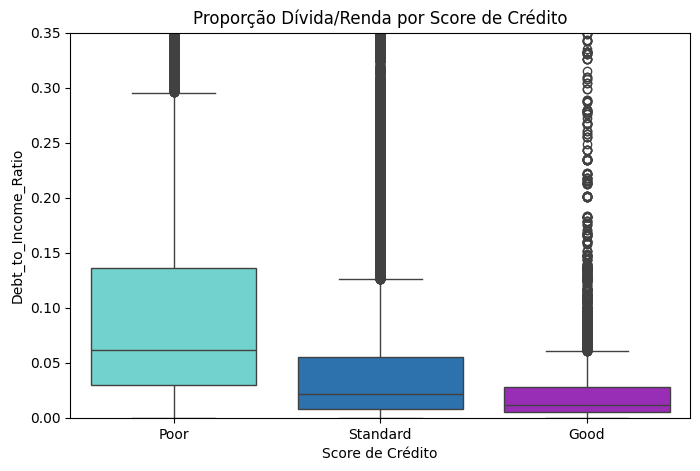

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x='Credit_Score',
    y='Debt_to_Income_Ratio',
    order=['Poor', 'Standard', 'Good'],
    hue='Credit_Score',
    palette=palette_score
)

plt.title('Proporção Dívida/Renda por Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Debt_to_Income_Ratio')
plt.ylim(0, 0.35)
plt.show()

### Anotações

- O grupo **Poor** apresentou a maior mediana de `Debt_to_Income_Ratio` (0,062), indicando que clientes com pior score comprometem proporcionalmente mais sua renda com dívidas.

- O grupo **Good** apresentou a menor mediana (0,012), aproximadamente 5 vezes menor que o grupo Poor, sugerindo que clientes com melhor score mantem um nível de endividamento saudável em relação a sua renda.

- O grupo **Standard** apresentou comportamento intermediário, com mediana de 0,022.

Essa variável captura o risco de forma mais precisa do que a dívida absoluta isolada, pois considera a capacidade de pagamento do cliente. Clientes com alta dívida e alta renda podem ser menos arriscados do que clientes com dívida menor, mas renda muito baixa.

# 📈 Etapa 3 — Análise Exploratória de Dados (EDA)

Nesta etapa da Análise Exploratória de Dados (EDA), serão avaliadas algumas variáveis associadas ao score de crédito compreendendo suas distribuições e seu comportamento, com o objetivo de identificar padrões que auxiliem na compreensão dos fatores relacionados ao risco de crédito.

**Como está distribuída a carteira de clientes da Data Girls Finance?**

### Bloco 1 — Distribuição do Score de Crédito

In [ ]:
#Frequência Absoluta
score_count = train['Credit_Score'].value_counts()

#Percentual
score_percent = train['Credit_Score'].value_counts(normalize=True).mul(100).round(2)

#Tabela comparativa
score_distribution = pd.DataFrame({
    'Frequencia Abs': score_count,
    'Percentual (%)': score_percent
})
score_distribution

,Frequencia Abs,Percentual (%)
Credit_Score,,
Standard,53174,53.17
Poor,28998,29.00
Good,17828,17.83


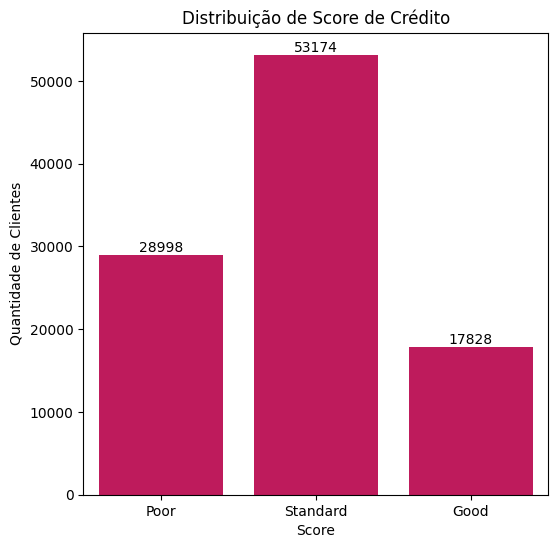

In [ ]:
plt.figure(figsize=(6,6))

ax = sns.countplot(
    data = train,
    x = 'Credit_Score',
    order = ['Poor','Standard','Good'],
    color = cor_neutra
)

plt.title('Distribuição de Score de Crédito')
plt.xlabel('Score')
plt.ylabel('Quantidade de Clientes')

for container in ax.containers:
    ax.bar_label(container)

plt.show()


### Anotações

- A maior parte dos clientes possui score de crédito classificado como **Standard** (53,17%), caracterizando uma carteira predominantemente composta por clientes de risco intermediário.

- A proporção de clientes com score **Poor** (29,00%) é superior à de clientes com score **Good** (17,83%), indicando uma participação significativa de clientes com maior risco de crédito.

- Analisando a distribuição, foi possível levantar o seguinte questionamento:  **Quais características financeiras e comportamentais estão associadas à classificação do score de crédito?**

**Fatores associados ao Score de Crédito**

A análise foi dividida em blocos: **características demográficas** (idade, renda e ocupação) e **características financeiras e comportamentais** (atrasos, endividamento, histórico e comportamento de pagamento), buscando identificar quais fatores estão mais associados ao risco de crédito.

### Bloco 1 - Características Demográficas

### Idade (Age)

A variável **Age** representa a idade dos clientes e pode estar relacionada ao comportamento financeiro, uma vez que diferentes fases da vida costumam apresentar perfis distintos de renda, endividamento e utilização de crédito.

Nesta análise, busca-se investigar se existe associação entre a idade dos clientes e a classificação do **Credit_Score**.

**Clientes com diferentes faixas etárias tendem a apresentar distribuições distintas de score de crédito?**

In [ ]:
train.groupby('Credit_Score')['Age'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17828.0,36.40,11.11,14.0,27.0,36.0,46.0,99.0
Poor,28998.0,31.19,9.98,14.0,23.0,31.0,39.0,56.0
Standard,53174.0,33.44,10.81,14.0,25.0,33.0,42.0,100.0


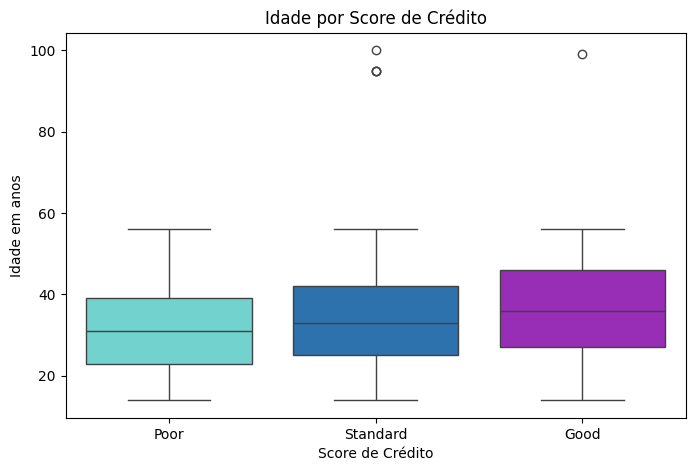

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data = train,
    x = 'Credit_Score',
    y = 'Age',
    order = ['Poor','Standard','Good'],
    hue='Credit_Score',
    palette=palette_score,
    legend=False
)

plt.title('Idade por Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Idade em anos')

plt.show()

É possível observar que as distribuições de idade dos grupos Poor e Standard se assemelham bastante, apresentando medianas e intervalos interquartis (IQR) semelhantes. O grupo Good apresentou uma dispersão ligeiramente maior, evidenciada por uma caixa mais ampla no boxplot, indicando maior variabilidade das idades entre esses clientes.

Comparando com a tabela de estatísticas descritivas, verifica-se que os valores de mínimo, máximo e dos quartis são bastante próximos entre as três categorias de score, o que reforça a semelhança das distribuições.

**A idade não demonstrou ser um fator determinante para a classificação do score de crédito**, sugerindo que o comportamento financeiro tem maior influência do que características demográficas como a faixa etária.

### Renda Anual (Annual_Income)

A renda anual representa a capacidade financeira do cliente e pode influenciar diretamente sua capacidade de pagamento e acesso ao crédito.

Nesta análise, busca-se investigar se existe associação entre a renda anual dos clientes e a classificação do **Credit_Score**.

**Clientes com maior renda anual tendem a apresentar melhores classificações de score de crédito?**


In [ ]:
train.groupby('Credit_Score')['Annual_Income'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17828.0,184936.59,1409982.81,7189.54,29892.37,45536.43,98967.87,24198062.0
Poor,28998.0,154979.03,1368526.18,7005.93,16857.29,32276.42,58367.36,23912939.0
Standard,53174.0,185249.16,1468143.76,7006.04,20078.47,37201.06,73910.61,24188807.0


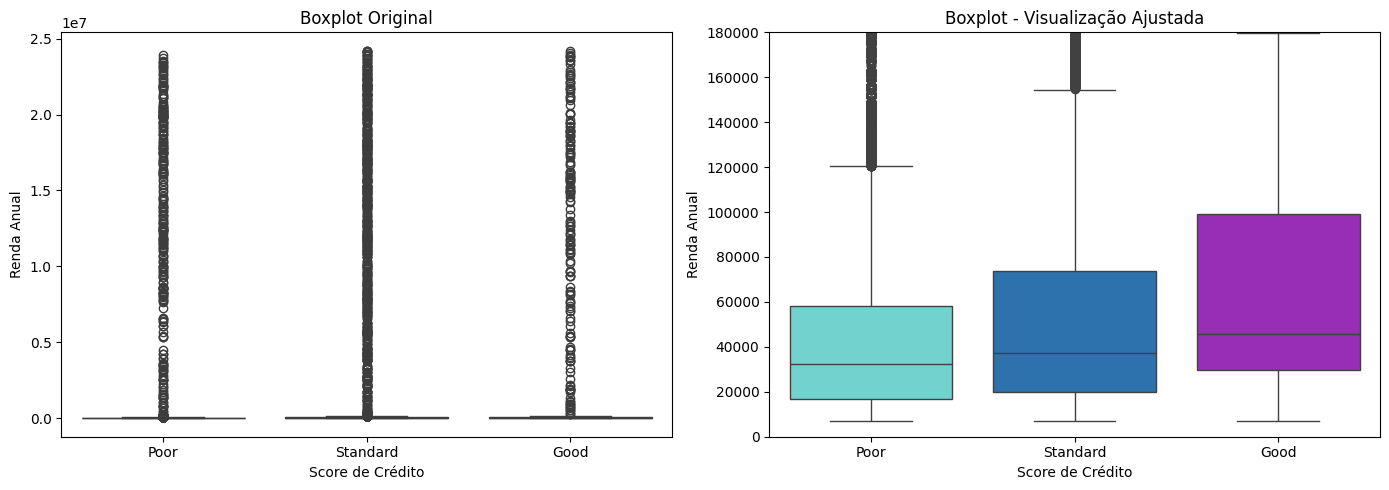

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original
sns.boxplot(
    data=train,
    x="Credit_Score",
    y="Annual_Income",
    order=["Poor", "Standard", "Good"],
     hue='Credit_Score',
    ax=axes[0]
)

axes[0].set_title("Boxplot Original")
axes[0].set_xlabel("Score de Crédito")
axes[0].set_ylabel("Renda Anual")

# Boxplot com limite no eixo Y
sns.boxplot(
    data=train,
    x="Credit_Score",
    y="Annual_Income",
    order=["Poor", "Standard", "Good"],
     hue='Credit_Score',
    palette=palette_score,
    ax=axes[1]
)

axes[1].set_ylim(0, 180000)   # limitando a visualização para no máximo 180 mil.
axes[1].set_title("Boxplot - Visualização Ajustada")
axes[1].set_xlabel("Score de Crédito")
axes[1].set_ylabel("Renda Anual")

plt.tight_layout()
plt.show()

*O boxplot original apresentou valores extremos de outliers, o que dificultou a interpretação da distribuição dos dados. Para melhorar a visualização, foi gerada uma versão ajustada com limite no eixo Y de 180 mil, permitindo observar melhor a dispersão e as medidas de tendência central. Importante destacar que todos os dados foram mantidos, sem remoção de observações.*

- O grupo **Good** apresentou a maior mediana de renda anual (R$ 59.619), além de um intervalo interquartil mais amplo, indicando maior variabilidade de renda entre clientes com melhor classificação de score.

- O grupo **Standard** apresentou mediana intermediária (R$ 47.979) e dispersão superior ao grupo Poor, sugerindo um perfil financeiro intermediário.

- O grupo **Poor** concentrou as menores rendas anuais, com mediana de R$ 36.176 e menor dispersão entre os três grupos.

Embora exista diferença entre os grupos, a sobreposição dos intervalos interquartis **indica que a renda anual, isoladamente, não é suficiente para determinar o score de crédito**,possivelmente outros fatores comportamentais possuem papel mais relevante.

### Profissão (Occupation)

A variável representa a profissão declarada pelo cliente e pode estar associada ao perfil de renda e comportamento financeiro.

Nesta análise, busca-se investigar se existe associação entre a profissão do cliente e a classificação do **Credit_Score**.

**Clientes de determinadas profissões tendem a apresentar distribuições distintas de score de crédito?**

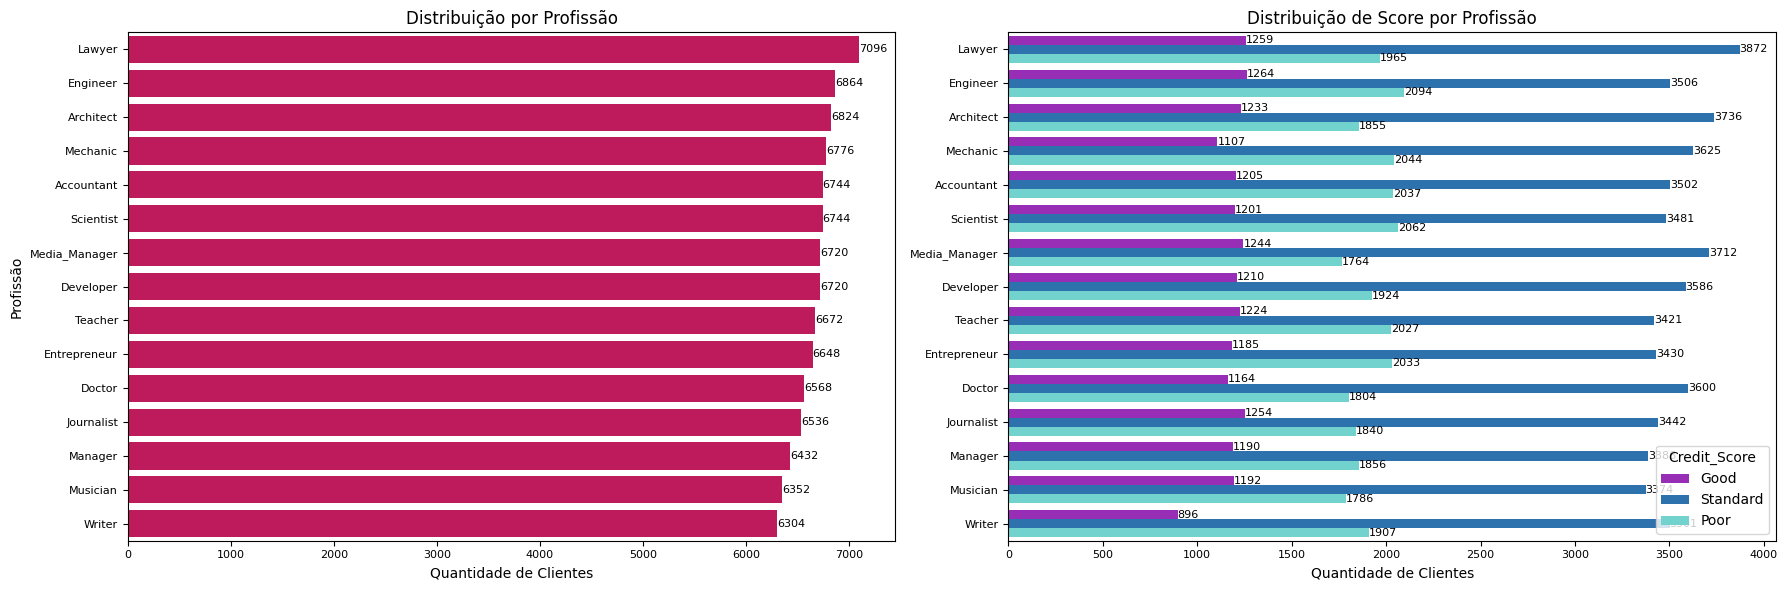

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribuição geral das profissões
ax1 = sns.countplot(
    data=train,
    y='Occupation',
    order=train['Occupation'].value_counts().index,
    ax=axes[0],
    color=cor_neutra
)
axes[0].set_title('Distribuição por Profissão')
axes[0].set_xlabel('Quantidade de Clientes')
axes[0].set_ylabel('Profissão')

axes[0].tick_params(axis='y', labelsize=8)
axes[0].tick_params(axis='x', labelsize=8)

# Score de crédito
ax2 = sns.countplot(
    data=train,
    y='Occupation',
    hue='Credit_Score',
    order=train['Occupation'].value_counts().index,
    ax=axes[1],
    palette=palette_score
)
axes[1].set_title('Distribuição de Score por Profissão')
axes[1].set_xlabel('Quantidade de Clientes')
axes[1].set_ylabel('')

axes[1].tick_params(axis='y', labelsize=8)
axes[1].tick_params(axis='x', labelsize=8)

for container in ax1.containers:
    ax1.bar_label(container, fontsize=8)
for container in ax2.containers:
    ax2.bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
#Contagem absoluta
occupation_score = (train.groupby(['Occupation','Credit_Score']).size().unstack(fill_value=0))

#Proporção em porcentagem de score dentro das profissões
occupation_score_percent = occupation_score.div(occupation_score.sum(axis=1), axis=0) * 100
print(occupation_score_percent.round(2))


Credit_Score    Good   Poor  Standard
Occupation                           
Accountant     17.87  30.20     51.93
Architect      18.07  27.18     54.75
Developer      18.01  28.63     53.36
Doctor         17.72  27.47     54.81
Engineer       18.41  30.51     51.08
Entrepreneur   17.82  30.58     51.59
Journalist     19.19  28.15     52.66
Lawyer         17.74  27.69     54.57
Manager        18.50  28.86     52.64
Mechanic       16.34  30.17     53.50
Media_Manager  18.51  26.25     55.24
Musician       18.77  28.12     53.12
Scientist      17.81  30.58     51.62
Teacher        18.35  30.38     51.27
Writer         14.21  30.25     55.54


* A análise de Occupation mostrou que a distribuição de clientes por profissão é relativamente equilibrada e que, dentro de cada ocupação, os scores de crédito se apresentam em proporções semelhantes.
Não foi identificada uma tendência clara que associe determinada ocupação a melhores ou piores classificações de crédito, **sugerindo que a profissão não é um fator determinante para o score**.

### Bloco 3 — Características Financeiras e Comportamentais

Após a análise das características demográficas, esta etapa investiga variáveis relacionadas ao comportamento financeiro dos clientes. Esses fatores estão diretamente associados ao risco de inadimplência e espera-se que apresentem maior capacidade de diferenciar as classificações de score de crédito.

###Atraso no pagamento (Delay_from_due_date)

Essa variável foi escolhida pois representa a quantidade de dias de atraso nos pagamentos em relação à data de vencimento.

A pontualidade no pagamento é um indicador importante do comportamento financeiro dos clientes e pode estar associada ao risco de crédito.

**Clientes com maior atraso médio de pagamento tendem a apresentar pior classificação de crédito?**

In [ ]:
train.groupby('Credit_Score')['Delay_from_due_date'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17828.0,10.89,8.46,-5.0,5.0,10.0,14.0,67.0
Poor,28998.0,29.74,16.31,-5.0,17.0,27.0,43.0,67.0
Standard,53174.0,19.75,12.99,-5.0,10.0,18.0,26.0,67.0


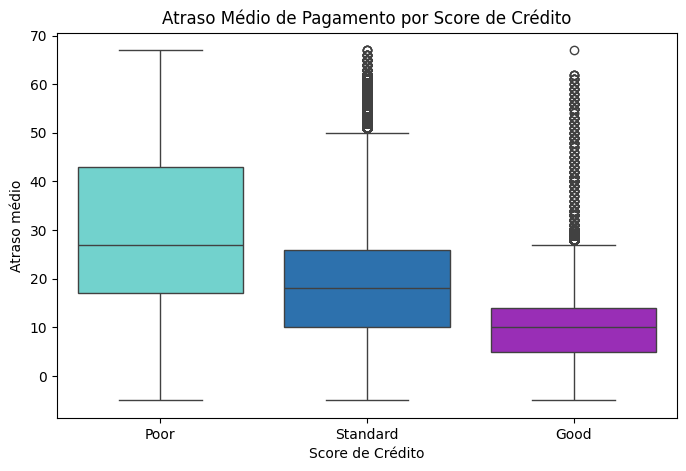

In [ ]:
plt.figure(figsize = (8,5))

sns.boxplot(
    data = train,
    x = 'Credit_Score',
    y = 'Delay_from_due_date',
    order = ['Poor','Standard','Good'],
    hue='Credit_Score',
    palette=palette_score,
    legend=False
)

plt.title('Atraso Médio de Pagamento por Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Atraso médio')
plt.show()

- O grupo **Poor** apresentou a maior mediana de atraso (27 dias) e a maior dispersão entre os grupos, indicando que clientes com baixo score tendem a atrasar seus pagamentos por períodos mais longos.

- O grupo **Standard** apresentou comportamento intermediário, com mediana de atraso de 18 dias e dispersão também intermediária, sugerindo um perfil de risco moderado.

- Já o grupo **Good** apresentou a menor mediana de atraso (10 dias) e a menor dispersão, sugerindo maior regularidade e pontualidade nos pagamentos.

- Foram observados diversos outliers nos grupos **Standard** e **Good**, representando clientes que, apesar de possuírem classificações de score mais elevadas, registraram atrasos superiores ao padrão do grupo.

De forma geral, observou-se uma relação consistente entre o aumento do atraso médio nos pagamentos e a pior classificação do score de crédito, i**ndicando que essa variável possui forte potencial para diferenciar clientes de maior e menor risco.**

### Dívida Pendente (Outstanding_Debt)

A variável **Outstanding_Debt** representa o valor da dívida pendente do cliente no momento da análise.

O nível de endividamento é um dos principais fatores considerados na avaliação de risco de crédito, desta forma, busca-se investigar se clientes com maiores dívidas pendentes tendem a apresentar classificações inferiores de score de crédito.

**Clientes com maior dívida pendente apresentam piores classificações de score de crédito?**

In [ ]:
train.groupby('Credit_Score')['Outstanding_Debt'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17828.0,801.26,612.36,0.23,382.35,736.47,1149.63,4998.07
Poor,28998.0,2081.47,1143.98,0.54,1338.74,1945.35,2598.36,4997.10
Standard,53174.0,1278.42,1132.71,0.23,490.98,1001.61,1454.48,4998.07


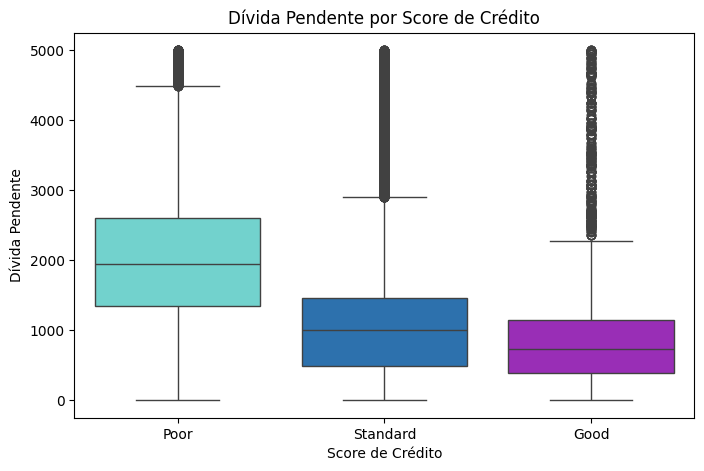

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x='Credit_Score',
    y='Outstanding_Debt',
    order=['Poor','Standard','Good'],
    hue='Credit_Score',
    palette=palette_score,
    legend=False
)

plt.title('Dívida Pendente por Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Dívida Pendente')
plt.show()

- O grupo Poor apresentou a maior mediana de dívida pendente (1.945) e a maior dispersão entre os grupos (Q1 = 1.339 e Q3 = 2.598), indicando que clientes com baixo score tendem a possuir níveis mais elevados de endividamento.

- O grupo Standard apresentou comportamento intermediário, com mediana de 1.002 e intervalo interquartil entre 491 e 1.454, caracterizando um perfil financeiro intermediário.

- O grupo Good apresentou a menor mediana de dívida (736) e menor nível de endividamento quando comparado aos demais grupos, embora também apresente variabilidade entre os clientes.

Para todos os grupos foram observados a presença de outliers, indicando a existência de clientes com elevado nível de endividamento independentemente da classificação de score. Esses casos poderão ser explorados posteriormente.

De modo geral, os resultados sugerem uma associação entre o aumento da dívida pendente e classificações mais baixas de score de crédito, indicando que **Outstanding_Debt pode ser uma das variáveis mais relevantes para diferenciar clientes de maior e menor risco.**

### Histórico de Crédito (Credit_History_TotalMonths)

A variável representa há quantos meses o cliente possui histórico de crédito.

Um histórico de crédito mais longo permite que as instituições financeiras avaliem o comportamento de pagamento ao longo do tempo, podendo contribuir para uma análise de risco mais consistente.

**Clientes com maior tempo de histórico de crédito tendem a apresentar melhores classificações de score de crédito?**

In [ ]:
train.groupby('Credit_Score')['Credit_History_TotalMonths'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Credit_Score,,,,,,,,
Good,17828.0,284.74,73.33,5.0,230.0,288.0,346.0,404.0
Poor,28998.0,170.05,87.53,1.0,104.0,161.0,222.0,404.0
Standard,53174.0,227.80,99.40,1.0,154.0,227.0,310.0,404.0


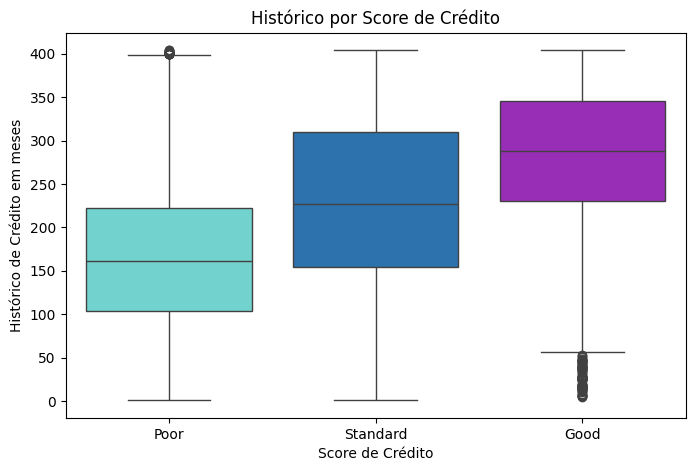

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data = train,
    x = 'Credit_Score',
    y = 'Credit_History_TotalMonths',
    order = ['Poor','Standard','Good'],
    hue='Credit_Score',
    palette=palette_score,
    legend=False
)

plt.title('Histórico por Score de Crédito')
plt.xlabel('Score de Crédito')
plt.ylabel('Histórico de Crédito em meses')
plt.show()


- O grupo **Poor** apresentou a menor mediana de histórico de crédito (161 meses), com intervalo interquartil entre 104 e 222 meses, indicando que clientes com pior score tendem a possuir um histórico de crédito mais curto.

- O grupo **Standard** apresentou comportamento intermediário, com mediana de 227 meses e intervalo interquartil entre 154 e 310 meses.

- O grupo **Good** apresentou a maior mediana (288 meses) e o maior tempo de histórico de crédito entre os grupos, sugerindo que clientes com melhor score possuem um perfil mais maduro no histórico de crédito. Além disso, há a presena de outliers interiores, representando clientes que, mesmo possuindo um crédito relativamente curto, alcançaram uma boa classificação de score. Isto pode ser um indicativo de que outros fatores também estão influenciando nesse perfil.

De forma geral, foi possível observar uma tendência de aumento do score de crédito à medida que cresce o tempo de histórico de crédito, **sugerindo que essa variável é um importante indicador na avaliação do risco de crédito.**

###Mix de Crédito (Credit_Mix)

A variável representa o nível de qualidade da composição de crédito que o cliente possui, considerando empréstimos pessoais, financiamentos, cartões de crédito e outros produtos financeiros.

Essa classificação, portanto, reflete como o cliente administra diferentes tipos de crédito, sendo categorizada em Good, Standard ou Bad.

**Clientes com classificação 'Good' em Credit_Mix tendem a apresentar melhores scores de crédito?**

In [ ]:
pd.crosstab(
    train["Credit_Mix"],
    train["Credit_Score"],
    normalize="index"
).round(3) * 100

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,1.5,60.1,38.4
Good,48.9,16.0,35.2
Standard,5.7,21.5,72.8


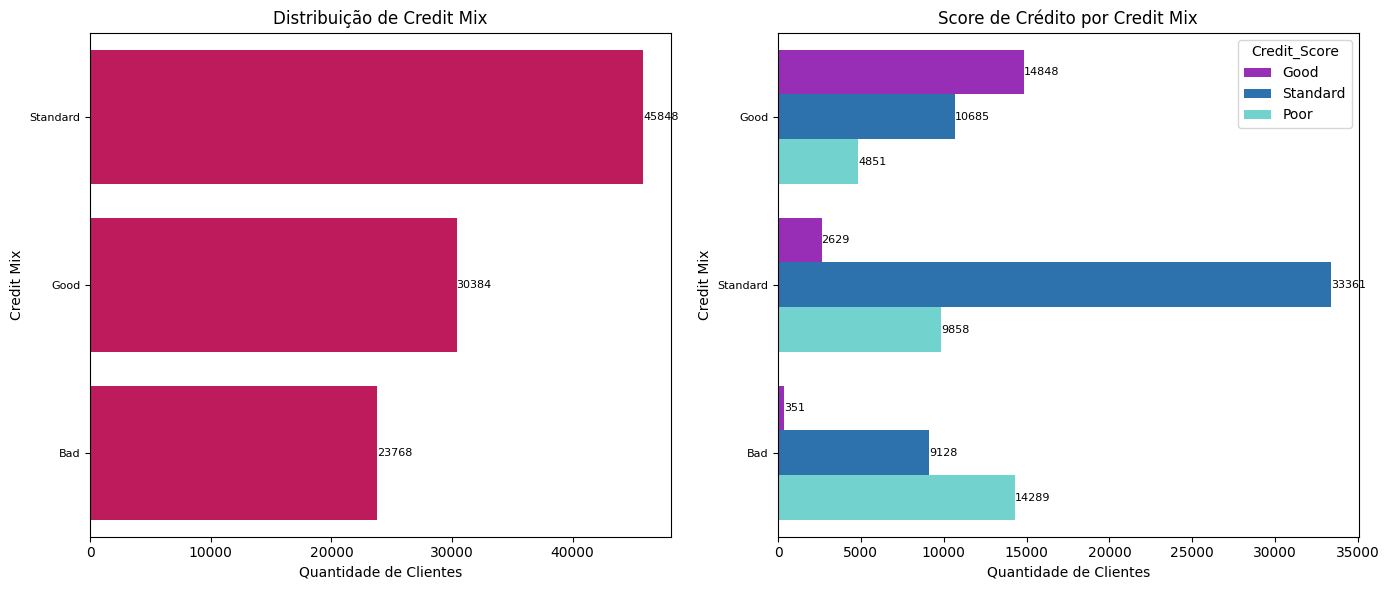

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Calculate frequency and percentage for Credit_Mix
credit_mix_counts = train['Credit_Mix'].value_counts()
credit_mix_percent = train['Credit_Mix'].value_counts(normalize=True).mul(100).round(2)

credit_mix_distribution = pd.DataFrame({
    'Frequencia Abs': credit_mix_counts,
    'Percentual (%)': credit_mix_percent
})

# Gráfico 1 - Distribuição geral de Credit Mix
sns.barplot(
    x=credit_mix_distribution['Frequencia Abs'],
    y=credit_mix_distribution.index,
    color=cor_neutra,
    ax=axes[0]
)
axes[0].set_title("Distribuição de Credit Mix")
axes[0].set_xlabel("Quantidade de Clientes")
axes[0].set_ylabel("Credit Mix")
axes[0].tick_params(axis='y', labelsize=8)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8)

# Gráfico 2 - Distribuição de Score por Credit Mix
sns.countplot(
    data=train,
    y='Credit_Mix',
    hue='Credit_Score',
    palette=palette_score,
    ax=axes[1]
)
axes[1].set_title("Score de Crédito por Credit Mix")
axes[1].set_xlabel("Quantidade de Clientes")
axes[1].set_ylabel("Credit Mix")
axes[1].tick_params(axis='y', labelsize=8)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=8)

plt.tight_layout()
plt.show()

- Entre os clientes classificados com **Credit_Mix = Bad**, 60,1% possuem score Poor, enquanto apenas 1,5% apresentam score Good, indicando uma forte associação entre um mix de crédito inadequado e maior risco de crédito.

- Para clientes com **Credit_Mix = Standard**, observa-se predominância do score Standard (72,8%), sugerindo um perfil financeiro intermediário.

- Já entre os clientes com **Credit_Mix = Good**, 48,9% possuem score Good, enquanto apenas 16,0% apresentam score Poor, evidenciando uma associação positiva entre um mix de crédito saudável e melhores classificações de score.

De forma geral, observa-se uma associação consistente entre a qualidade do Credit_Mix e a classificação do score de crédito, indicando que essa **variável possui elevado potencial para diferenciar clientes de maior e menor risco.**

###Comportamento de Pagamento (Payment_Behaviour)

A variável **Payment_Behaviour** descreve o padrão de gastos do cliente, combinando o nível de gastos (High ou Low) com o valor predominante das transações (Small, Medium ou Large).


**Existe associação entre o padrão de gastos dos clientes e a classificação do score de crédito?**

In [ ]:
train['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments'], dtype=object)

Observou-se que a variável **Payment_Behaviour** combina duas informações em uma única coluna: nível de gasto (High/Low) e valor das transações (Small/Medium/Large).


Devido à quantidade de categorias, será realizada uma etapa de **Feature Engineering**, separando essa variável em dois componentes para facilitar a interpretação dos resultados.

In [ ]:
#Nível de gasto separado em High e Low
train['Spending_Level'] = train['Payment_Behaviour'].str.extract(r'^(High|Low)')

#Valor das transações em Small, Medium e Large
train['Payment_Size'] = train['Payment_Behaviour'].str.extract(r'_(Small|Medium|Large)_')

train[['Payment_Behaviour','Spending_Level','Payment_Size']].head()
#Tabelas validadas!

,Payment_Behaviour,Spending_Level,Payment_Size
0,High_spent_Small_value_payments,High,Small
1,Low_spent_Large_value_payments,Low,Large
2,Low_spent_Medium_value_payments,Low,Medium
3,Low_spent_Small_value_payments,Low,Small
4,High_spent_Medium_value_payments,High,Medium


In [ ]:
print(train["Spending_Level"].value_counts())

print()

print(train["Payment_Size"].value_counts())

Spending_Level
Low     53306
High    46694
Name: count, dtype: int64

Payment_Size
Small     39747
Medium    33987
Large     26266
Name: count, dtype: int64


A variável **Payment_Behaviour** reúne duas informações distintas em uma única categoria: o **nível de gasto do cliente** (High ou Low) e o **valor predominante das transações** (Small, Medium ou Large).

Desta forma, a variável foi desmembrada em duas categorias:

- **Spending_Level:** classifica o cliente quanto ao nível de gastos (High ou Low);

- **Payment_Size:** refere-se ao valor das transações (Small, Medium ou Large).

Desta forma, é possível analisar separadamente o impacto do nível de gastos e do perfil das transações na classificação do score de crédito.

In [ ]:
#Tabela Spending Level
pd.crosstab(
    train['Spending_Level'],
    train['Credit_Score'],
    normalize='index'
).round(3)*100

Credit_Score,Good,Poor,Standard
Spending_Level,,,
High,20.7,24.8,54.5
Low,15.3,32.7,52.0


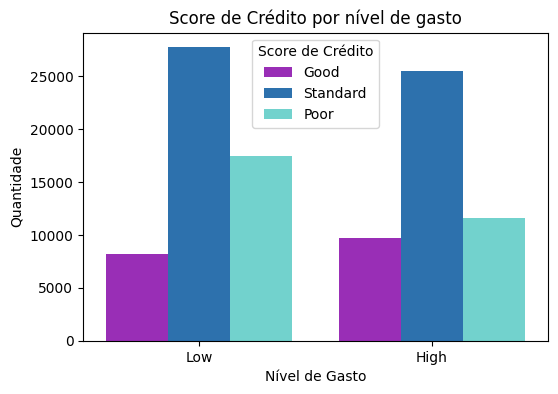

In [ ]:
#Gráfico Spending Level
plt.figure(figsize=(6,4))
sns.countplot(
    data=train,
    x='Spending_Level',
    hue='Credit_Score',
    order=['Low','High'],
    palette=palette_score
)
plt.title('Score de Crédito por nível de gasto')
plt.xlabel('Nível de Gasto')
plt.ylabel('Quantidade')
plt.legend(title='Score de Crédito')
plt.show()


- Clientes classificados como High Spending, a maior parte possui score Standard (54,5%), seguida por Poor (24,8%) e Good (20,7%).

- Clientes classificados como Low Spending, observa-se uma maior proporção de clientes com score Poor (32,7%) quando comparado ao grupo High Spending (24,8%).

- A proporção de clientes com score Good é superior entre os clientes High Spending (20,7%) em relação aos clientes Low Spending (15,3%).

**Os resultados sugerem que o nível de gastos, isoladamente, não está associado a um pior score de crédito.** Isto é, clientes com maior volume de gastos não necessariamente representam maiores riscos de crédito. Possivelmente outras variáveis, como renda, histórico de crédito e comportamento de pagamento, tem mais influência na classificação do score.

In [ ]:
# Tabela Payment Size
pd.crosstab(
    train['Payment_Size'],
    train['Credit_Score'],
    normalize='index'
).round(3) * 100

Credit_Score,Good,Poor,Standard
Payment_Size,,,
Large,21.1,24.4,54.5
Medium,19.1,27.7,53.2
Small,14.6,33.1,52.2


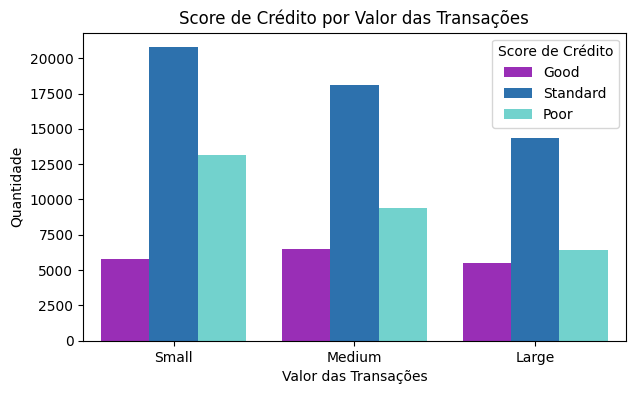

In [ ]:
#Gráfico Payment Size

plt.figure(figsize=(7,4))
sns.countplot(
    data=train,
    x='Payment_Size',
    hue='Credit_Score',
    order=['Small','Medium','Large'],
    palette=palette_score
)
plt.title('Score de Crédito por Valor das Transações')
plt.xlabel('Valor das Transações')
plt.ylabel('Quantidade')
plt.legend(title='Score de Crédito')
plt.show()

### Bloco 4 — Número de Contas, Cartões e Empréstimos

As variáveis `Num_Bank_Accounts`, `Num_Credit_Card` e `Num_of_Loan` representam, respectivamente, a quantidade de contas bancárias, cartões de crédito e empréstimos ativos do cliente.

**Existe relação entre essas variáveis e a classificação do score de crédito?**

In [ ]:
for col in ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']:
    print(f"\n{col}")
    print(train.groupby('Credit_Score')[col].describe().round(2))


Num_Bank_Accounts
                count  mean   std  min  25%  50%  75%   max
Credit_Score                                               
Good          17828.0  3.44  2.22  0.0  2.0  3.0  5.0  10.0
Poor          28998.0  6.53  2.51  0.0  5.0  7.0  8.0  11.0
Standard      53174.0  5.38  2.36  0.0  4.0  5.0  7.0  18.0

Num_Credit_Card
                count  mean   std  min  25%  50%  75%   max
Credit_Score                                               
Good          17828.0  4.14  1.81  0.0  3.0  4.0  5.0  10.0
Poor          28998.0  6.63  1.99  1.0  5.0  7.0  8.0  15.0
Standard      53174.0  5.40  1.86  0.0  4.0  5.0  7.0  15.0

Num_of_Loan
                count  mean   std  min  25%  50%  75%  max
Credit_Score                                              
Good          17828.0  2.20  1.65  0.0  1.0  2.0  3.0  9.0
Poor          28998.0  4.76  2.44  0.0  3.0  5.0  7.0  9.0
Standard      53174.0  3.31  2.38  0.0  1.0  3.0  5.0  9.0


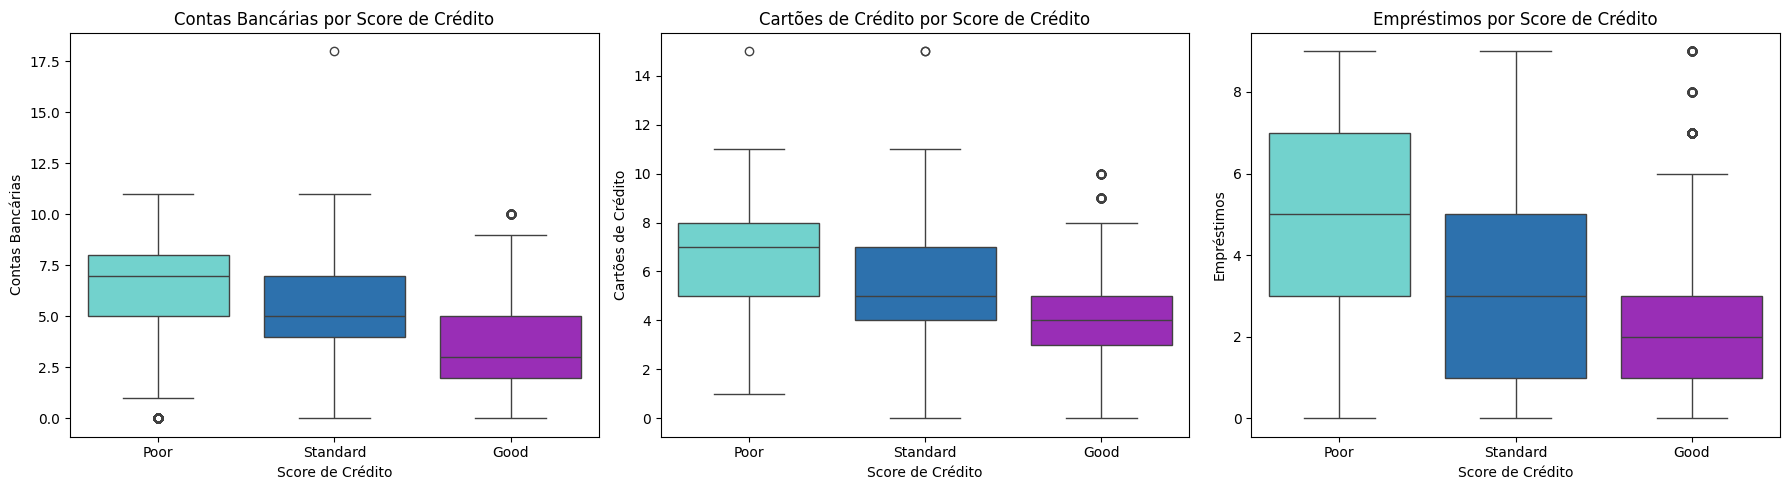

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variaveis = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']
titulos = ['Contas Bancárias', 'Cartões de Crédito', 'Empréstimos']

for ax, col, titulo in zip(axes, variaveis, titulos):
    sns.boxplot(
        data=train,
        x='Credit_Score',
        y=col,
        order=['Poor', 'Standard', 'Good'],
        hue='Credit_Score',
        palette=palette_score,
        legend=False,
        ax=ax
    )
    ax.set_title(f'{titulo} por Score de Crédito')
    ax.set_xlabel('Score de Crédito')
    ax.set_ylabel(titulo)

plt.tight_layout()
plt.show()

- O grupo **Good** apresentou as menores medianas em todas as três variáveis: 3 contas bancárias, 4 cartões de crédito e 2 empréstimos, sugerindo que clientes com melhor score tendem a manter um carteira de crédito menor.

- O grupo **Poor** concentrou as maiores medianas: 7 contas bancárias, 7 cartões de crédito e 5 empréstimos, indicando que o acúmulo de produtos financeiros está associado a piores classificações de score.

- O grupo **Standard** apresentou comportamento intermediário nas três variáveis, com medianas de 5 contas, 5 cartões e 3 empréstimos.

De forma geral, os resultados **sugerem que clientes com maior número de contas bancárias, cartões de crédito e empréstimos ativos tendem a apresentar piores classificações de score de crédito**, indicando que o acúmulo de produtos financeiros pode ser um indicador de risco relevante para a Data Girls Finance.

### Validação Estatística — Teste de Kruskal-Wallis

Para complementar as análises visuais realizadas, foi aplicado o teste de Kruskal-Wallis nas variáveis mais relevantes identificadas durante o EDA.

O teste verifica se existe diferença estatisticamente significativa entre as distribuições dos grupos de score de crédito (Poor, Standard e Good). Como as variáveis não seguem distribuição normal e os grupos possuem tamanhos diferentes, o Kruskal-Wallis é o teste não-paramétrico mais adequado para essa comparação.

- **H₀ (hipótese nula):** as distribuições dos grupos são iguais
- **H₁ (hipótese alternativa):** pelo menos um grupo apresenta distribuição diferente
- **Critério de decisão:** p < 0,05 → rejeita H₀

In [ ]:
variaveis = [
    'Delay_from_due_date',
    'Outstanding_Debt',
    'Credit_History_TotalMonths',
    'Annual_Income'
]

for col in variaveis:
    grupos = [train[train['Credit_Score'] == score][col].dropna()
        for score in ['Poor', 'Standard', 'Good']]
    stat, p = kruskal(*grupos)
    print(f"{col}: H={stat:.2f}, p={p:.4f}")

Delay_from_due_date: H=19455.08, p=0.0000
Outstanding_Debt: H=19399.61, p=0.0000
Credit_History_TotalMonths: H=15824.66, p=0.0000
Annual_Income: H=4182.74, p=0.0000


### Resultados

| Variável | H | p-valor |
|---|---|---|
| Delay_from_due_date | 19.455,08 | < 0,001 |
| Outstanding_Debt | 19.399,61 | < 0,001 |
| Credit_History_TotalMonths | 15.824,66 | < 0,001 |
| Annual_Income | 4.182,74 | < 0,001 |

Para todas as variáveis analisadas, o teste de Kruskal-Wallis resultou em p < 0,001, indicando que há diferença estatisticamente significativa entre os grupos de score de crédito em todas as variáveis testadas. Vale destacar que, com uma amostra de 100.000 clientes, o teste tende a detectar significância mesmo para diferenças pequenas, desta forma, a significância estatística confirma que a diferença existe, mas não deve ser considerada isoladamente como medida de quão grande ou relevante ela é na prática.

Diante disso, `Delay_from_due_date` e `Outstanding_Debt` apresentaram os maiores valores de H entre as variáveis testadas, o que é consistente com o que já havia sido observado na análise exploratória (maior dispersão e separação visual entre os grupos nos boxplots).Com isso, enfatizamos a escolha dessas duas variáveis como principais indicadores de risco na Data Girls Finance.


#### Teste Qui-Quadrado — Credit_Mix

Para a variável categórica `Credit_Mix`, o teste de Kruskal-Wallis não é aplicável. O teste adequado é o **Qui-quadrado de independência**, que verifica se existe associação entre duas variáveis categóricas.

- **H₀:** não existe associação entre `Credit_Mix` e `Credit_Score`
- **H₁:** existe associação entre `Credit_Mix` e `Credit_Score`
- **Critério de decisão:** p < 0,05 → rejeita H₀

In [ ]:

tabela = pd.crosstab(train['Credit_Mix'], train['Credit_Score'])
stat, p, dof, expected = chi2_contingency(tabela)

print(f"Qui-quadrado: {stat:.2f}")
print(f"Graus de liberdade: {dof}")
print(f"p-valor: {p:.4f}")

Qui-quadrado: 40489.42
Graus de liberdade: 4
p-valor: 0.0000


#### Resultado

| Teste | Estatística | Graus de liberdade | p-valor |
|---|---|---|---|
| Qui-quadrado | 40.489,42 | 4 | < 0,001 |

O teste Qui-quadrado confirmou que existe associação estatisticamente significativa entre `Credit_Mix` e `Credit_Score` (p < 0,001), rejeitando a hipótese nula de independência entre as variáveis.

A estatística qui-quadrado de 40.489,42 é expressiva, indicando que a composição do mix de crédito do cliente não é independente da sua classificação de score. Esse resultado reforça o uso do `Credit_Mix` como uma das variáveis de risco na Data Girls Finance.

## 🔗 Etapa 4 — Análise de Correlação

Após a análise individual das principais variáveis, esta etapa quantifica a associação entre as variáveis numéricas e o **Credit_Score** por meio da correlação de Spearman.

**Quais variáveis apresentam maior associação com o score de crédito?**

In [ ]:
#Transformando target para numérico
score_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

train['Credit_Score_Num'] = train['Credit_Score'].map(score_map)

#Variáveis de correlação
corr_cols = [
    "Credit_Score_Num",
    "Delay_from_due_date",
    "Outstanding_Debt",
    "Credit_History_TotalMonths",
    "Annual_Income",
    "Age",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries"
]

#Calculando a correlação de Spearman
corr = train[corr_cols].corr(method="spearman")


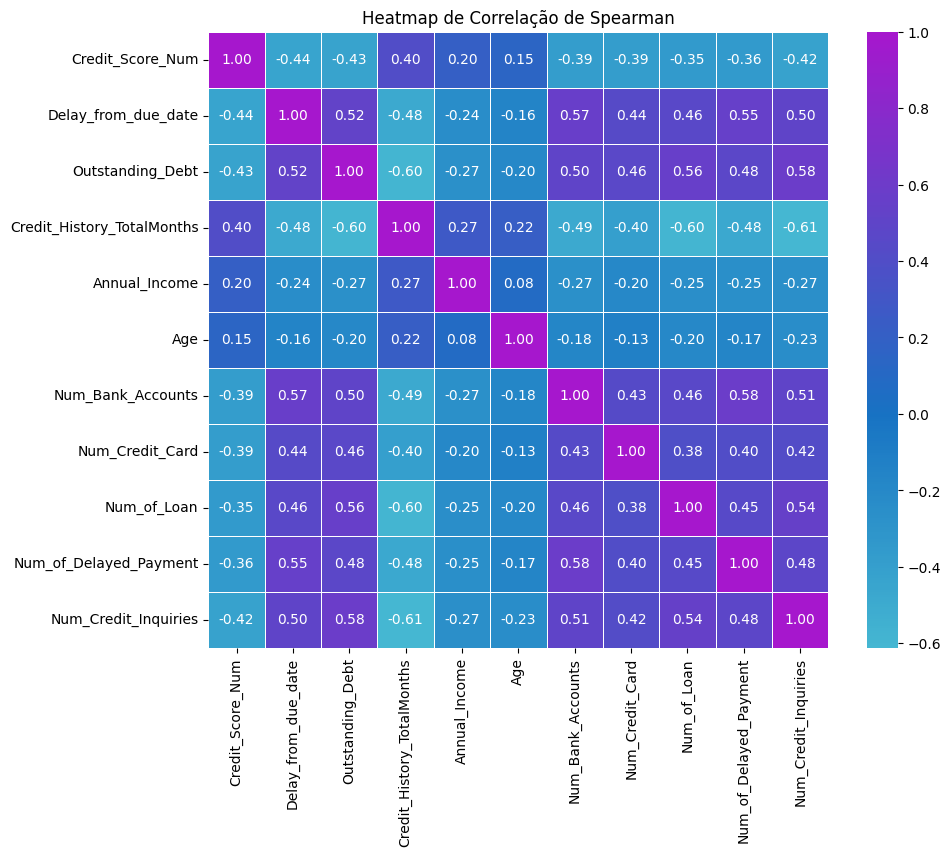

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap = sns.blend_palette(["#62E2DB", "#1772C3", "#A617CD"], as_cmap=True),
    center=0,
    linewidths=0.5
)


plt.title("Heatmap de Correlação de Spearman")
plt.show()

O heatmap de correlação de Spearman foi utilizado para quantificar a associação monotônica entre as variáveis numéricas e o **Credit_Score**, complementando as análises realizadas anteriormente.


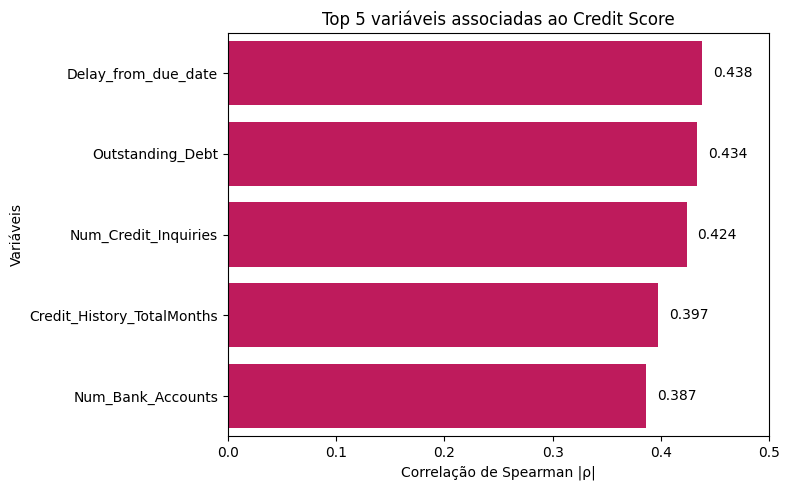

In [ ]:
# Top 5 correlações com Credit_Score (valor absoluto)
top5 = (
    corr["Credit_Score_Num"].drop("Credit_Score_Num").abs().sort_values(ascending=False).head(5)
)


#Gráfico top 5

plt.figure(figsize=(8,5))

sns.barplot(
    x=top5.values,
    y=top5.index,
    color=cor_neutra
)

plt.title("Top 5 variáveis associadas ao Credit Score")
plt.xlabel("Correlação de Spearman |ρ|")
plt.ylabel("Variáveis")

plt.xlim(0, 0.5)

for i, v in enumerate(top5.values):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

### Anotações

A análise de correlação confirmou quantitativamente os padrões identificados durante a Análise Exploratória de Dados, evidenciando que variáveis relacionadas ao comportamento financeiro e ao histórico de crédito apresentam maior associação com a classificação do score.

- O heatmap de correlação de Spearman revelou que as variáveis com maior associação ao `Credit_Score` são de natureza comportamental e financeira. As cinco maiores correlações em valor absoluto foram: `Delay_from_due_date` (ρ = -0,44), `Outstanding_Debt` (ρ = -0,43), `Num_Credit_Inquiries` (ρ = -0,42), `Credit_History_TotalMonths` (ρ = +0,40) e `Num_Bank_Accounts` (ρ = -0,38).

- As correlações negativas indicam que maiores atrasos, maior endividamento, mais consultas de crédito e mais contas bancárias estão associados a piores classificações de score. A única correlação positiva relevante é o tempo de histórico de crédito, quanto maior, melhor o score.

Esses resultados complementam as análises realizadas ao longo do EDA e servirão de base para a construção do dashboard e para a elaboração das recomendações estratégicas à Data Girls Finance.

## 💡 Etapa 5 — Conclusões e Recomendações

A análise identificou um perfil de risco claro: clientes com **Credit_Mix** inadequado, **alto comprometimento de renda** (DTI) e **atrasos recorrentes** de pagamento respondem por **29% da carteira** e concentram a maior parte do **risco de inadimplência**. As variáveis Delay_from_due_date, Outstanding_Debt e Credit_Mix são os indicadores mais discriminantes e devem ser priorizados em políticas de concessão, monitoramento e no dashboard de risco.

### 5.1 — Respostas às Perguntas Norteadoras
**1. Qual perfil tem maior risco de inadimplência (baixo score)?**

*Clientes com Credit_Mix = Bad (60,1% classificados como Poor), Debt_to_Income_Ratio mediano de 0,062, 5x acima do grupo Good, histórico de crédito curto (mediana de 161 meses) e atraso médio acima de 27 dias. Esse perfil representa 29,0% da carteira analisada e deve ser tratado como prioridade em políticas de concessão.*

**2. Quais fatores mais influenciam clientes com score Poor?**

*Os fatores com maior associação estatística ao score Poor (Kruskal-Wallis, p < 0,001) foram Delay_from_due_date (H = 19.455), Outstanding_Debt (H = 19.399) e Credit_History_TotalMonths (H = 15.824), indicadores comportamentais e de histórico superam, em poder discriminatório, variáveis demográficas.*

**3. Existe relação entre renda, contas bancárias, cartões e empréstimos com o score?**

*Sim. Clientes Good concentram menos produtos financeiros ativos (3 contas, 4 cartões, 2 empréstimos) e maior renda mediana (R$ 45.536) que clientes Poor (7 contas, 7 cartões, 5 empréstimos; R$ 32.276), diferença estatisticamente confirmada (Kruskal-Wallis, H = 4.182, p < 0,001).*

**4. Clientes com maior atraso médio de pagamento tendem a apresentar pior score?**

*Sim, de forma significativa. A mediana de atraso do grupo Poor (27 dias) é 2,7x maior que a do grupo Good (10 dias), confirmado estatisticamente (H = 19.455, p < 0,001) e identificado como a variável de maior poder discriminatório da análise.*


### 5.2 — Recomendações para a Data Girls Finance

| Passo | Ação | Justificativa | Impacto Esperado |
|---|------|-------------|-----------------|
| 1 | Triagem automática para `Credit_Mix = Bad` | 60,1% de probabilidade de score Poor nesse grupo | Redução de exposição sem aumento de headcount |
| 2 | Alerta de `Debt_to_Income_Ratio` > 0,062 | Mediana do grupo Poor; indicador direto de comprometimento de renda | Política de limites mais conservadora e proativa |
| 3 | Alerta operacional para atraso médio > 20 dias | Threshold entre mediana Standard (18d) e Poor (27d); ponto de inflexão de risco | Revisão automática da linha de crédito |
| 4 | Ofertas diferenciadas para Standard "quase-Good" | 53,2% da carteira; segmento com `Credit_History_TotalMonths` > 227 meses e DTI < 0,022 | Retenção e upgrade de score de clientes de baixo risco |
| 5 | Educação financeira para clientes com acúmulo de produtos | Perfil Poor concentra 7 contas, 7 cartões, 5 empréstimos | Redução de obrigações ativas e consolidação de dívidas |



Essa análise serviu como base para a construção do **dashboard interativo** no **Power BI**. As variáveis com maior poder discriminatório — `Delay_from_due_date`, `Outstanding_Debt`, `Credit_Mix` e `Debt_to_Income_Ratio` — foram priorizadas nas visualizações, permitindo que a equipe da Data Girls Finance monitore os principais indicadores de risco de forma dinâmica e tome decisões de concessão de crédito com maior embasamento analítico.

## ⌯⌲ Etapa 6 - Exportação para POWER BI

Nesta etapa, o dataset limpo é adaptado para uso no Power BI. As principais transformações aplicadas são: tradução dos valores categóricos e nomes das colunas para português, criação das variáveis `Nivel_Gasto` e `Tamanho_Pagamento` derivadas de `Payment_Behaviour`, e remoção de colunas não utilizadas no dashboard.

In [ ]:

train_dashboard = train.copy()


#Tradução dos dados

traducao_credit_score = {
    'Poor': 'Ruim',
    'Standard': 'Regular',
    'Good': 'Bom'
}

traducao_credit_mix = {
    'Bad': 'Inadequado',
    'Standard': 'Regular',
    'Good': 'Bom'
}

traducao_ocupacao = {
    'Scientist': 'Cientista',
    'Teacher': 'Professor',
    'Engineer': 'Engenheiro',
    'Entrepreneur': 'Empreendedor',
    'Developer': 'Desenvolvedor',
    'Lawyer': 'Advogado',
    'Media_Manager': 'Gerente de Mídias Sociais',
    'Doctor': 'Médico',
    'Journalist': 'Jornalista',
    'Manager': 'Gerente',
    'Accountant': 'Contador',
    'Musician': 'Músico',
    'Mechanic': 'Mecânico',
    'Writer': 'Escritor',
    'Architect': 'Arquiteto'
}


train_dashboard['Credit_Score'] = train_dashboard['Credit_Score'].replace(traducao_credit_score)
train_dashboard['Credit_Mix'] = train_dashboard['Credit_Mix'].replace(traducao_credit_mix)
train_dashboard['Occupation'] = train_dashboard['Occupation'].replace(traducao_ocupacao)


# Reaproveitando colunas da feature
train_dashboard['Nivel_Gasto'] = train_dashboard['Spending_Level'].replace({
    'High': 'Alto',
    'Low': 'Baixo'
})

train_dashboard['Tamanho_Pagamento'] = train_dashboard['Payment_Size'].replace({
    'Small': 'Pequeno',
    'Medium': 'Medio',
    'Large': 'Grande'
})


#Removendo colunas

colunas_remover = [
    'Payment_Behaviour',
    'Monthly_Balance',
    'ID',
    'Month',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Type_of_Loan',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Payment_of_Min_Amount',
    'Credit_Utilization_Ratio',
    'Changed_Credit_Limit',
    'Credit_Score_Num',
    'Spending_Level',
    'Payment_Size'
    ]

train_dashboard.drop(columns=colunas_remover, inplace=True)

#Renomeando colunas restante
traducao_colunas = {
    'Customer_ID': 'ID_Cliente',
    'Age': 'Idade',
    'Occupation': 'Profissao',
    'Annual_Income': 'Renda_Anual',
    'Delay_from_due_date': 'Dias_Atraso',
    'Num_of_Delayed_Payment': 'Num_Pagamentos_Atrasados',
    'Num_Credit_Inquiries': 'Num_Consultas_Credito',
    'Credit_Mix': 'Mix_Credito',
    'Outstanding_Debt': 'Divida_Pendente',
    'Credit_Score': 'Score_Credito',
    'Credit_History_TotalMonths': 'Historico_Credito_Meses',
    'Debt_to_Income_Ratio': 'Comprometimento_Renda'
}

train_dashboard.rename(columns=traducao_colunas, inplace=True)

In [ ]:
train_dashboard.head(2)

,ID_Cliente,Idade,Profissao,Renda_Anual,Dias_Atraso,Num_Pagamentos_Atrasados,Num_Consultas_Credito,Mix_Credito,Divida_Pendente,Score_Credito,Historico_Credito_Meses,Comprometimento_Renda,Nivel_Gasto,Tamanho_Pagamento
0,CUS_0xd40,23,Cientista,19114.12,3,7.0,4.0,Bom,809.98,Bom,265.0,0.042376,Alto,Pequeno
1,CUS_0xd40,23,Cientista,19114.12,-1,6.5,4.0,Bom,809.98,Bom,268.5,0.042376,Baixo,Grande


In [ ]:
# Exportando o CSV para ser utilizado no POWER BI
train_dashboard.to_csv('train_dashboard.csv', index=False)